In [ ]:
# Instalación mínima para Google Colab
!pip install -q pandas numpy matplotlib seaborn scikit-learn joblib kagglehub


In [ ]:
#importamos librerias y dependencias y las configuraciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import glob
import kagglehub
import os


#opciones para la visualizacion de las tablas
pd.set_option('display.max_columns', None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

#configuracion de graficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#gestion de warning
warnings.filterwarnings('ignore')

print("Configuración del entorno\n")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Configuración del entorno

Pandas: 2.2.2
Numpy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


Para trabajar con el dataset, lo más rápido es tener una copia del original en la carpeta compartida de DRIVE dataset/original/data.csv, descargarla en local e ir subiendo a esa carpeta compartida las distintas versiones ya editadas en dataset/limpio_versiones/ con el formato data_persona_v01.csv y un comentario en dicord de lo que se ha hecho en esa version.

In [ ]:
#para cargar el dataset lo mas sencillo es tener una copia master en drive y
#descargarla en local y luego cargarla en el notebook
from google.colab import files
dataset = files.upload()

Saving data.csv to data.csv


In [ ]:
# cargamos el dataset y mostramos 5 filas aleatorias del dataset
try:
    nombre_archivo = list(dataset.keys())[0]
    df = pd.read_csv(nombre_archivo, encoding="cp1252")
    print(f"Archivo {nombre_archivo} cargado exitosamente.")
    display(df.sample(5))
except FileNotFoundError:
    print(f"Error: No se encontró el archivo: {nombre_archivo}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Archivo data.csv cargado exitosamente.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
351684,567668,22170,PICTURE FRAME WOOD TRIPLE PORTRAIT,1,9/21/2011 15:29,13.29,NaN,United Kingdom
464399,576093,22402,MAGNETS PACK OF 4 VINTAGE COLLAGE,12,11/14/2011 9:05,0.39,"17,744.00",United Kingdom
168975,551152,23207,LUNCH BAG ALPHABET DESIGN,2,4/26/2011 14:47,1.65,"13,230.00",United Kingdom
20866,538071,21980,PACK OF 12 RED RETROSPOT TISSUES,1,12/9/2010 14:09,0.85,NaN,United Kingdom
382038,569897,21257,VICTORIAN SEWING BOX MEDIUM,1,10/6/2011 16:01,7.95,"17,813.00",United Kingdom


In [ ]:
#Vista general del dataset

#Dimensiones de dataset
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

#Nombres de las columnas.
print("\nNombres de las columnas:")
print(df.columns)

#Primeras y ultimas 5 filas del dataset
print("\nPrimeras 5 filas del dataset:")
display(df.head())
print("\nUltimas 5 filas del dataset:")
display(df.tail())

#tipos de datos y estructura
print("\nTipos de datos y estructura del dataset:")
display(df.info())

#resumen estadistico
print("\nResumen estadístico y descriptivo del dataset:")
display(df.describe(include=['object', 'int64', 'float64']))

#resumen descriptivo
#print("\nResumen descriptivo del dataset:")
#display(df.describe(include=['object', 'int64', 'float64']))



Dimensiones del dataset:
Filas: 541909
Columnas: 8

Nombres de las columnas:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'], dtype='object')

Primeras 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom



Ultimas 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,"12,680.00",France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,"12,680.00",France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,"12,680.00",France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,"12,680.00",France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,"12,680.00",France



Tipos de datos y estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


None


Resumen estadístico y descriptivo del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,"541,909.00",541909,"541,909.00","406,829.00",541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.55,NaN,4.61,"15,287.69",NaN
std,NaN,NaN,NaN,218.08,NaN,96.76,"1,713.60",NaN
min,NaN,NaN,NaN,"-80,995.00",NaN,"-11,062.06","12,346.00",NaN
25%,NaN,NaN,NaN,1.00,NaN,1.25,"13,953.00",NaN
50%,NaN,NaN,NaN,3.00,NaN,2.08,"15,152.00",NaN
75%,NaN,NaN,NaN,10.00,NaN,4.13,"16,791.00",NaN


In [ ]:
#Identificar valores duplicados

duplicados = df.duplicated().sum()
porcentaje_duplicados = (duplicados / len(df)) * 100

print("\n--- Detección de filas duplicadas ---")
print(f"Número de filas duplicadas: {duplicados}")
print(f"Porcentaje de filas duplicadas: {porcentaje_duplicados:.2f}%")

if duplicados > 0:
    print("\nMostrando las primeras 10 filas involucradas en duplicados:")

    duplicados_ejemplo = (
        df[df.duplicated(keep=False)]
        .sort_values(by=df.columns.tolist())
        .head(10)
    )

    display(duplicados_ejemplo)
else:
    print("\nNo se encontraron filas duplicadas en el DataFrame.")

if duplicados > 0:
    print(
        "Se han detectado filas repetidas exactamente en todas sus columnas. "
        "\nEsto sugiere la posible existencia de registros redundantes que deberán "
        "revisarse antes de la fase de limpieza."
    )
else:
    print("\nInterpretación inicial:")
    print("No se han detectado duplicados exactos, por lo que no sería necesario tratarlos.")


--- Detección de filas duplicadas ---
Número de filas duplicadas: 5268
Porcentaje de filas duplicadas: 0.97%

Mostrando las primeras 10 filas involucradas en duplicados:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,"17,908.00",United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,"17,908.00",United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,"17,908.00",United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,"17,908.00",United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,"17,908.00",United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,"17,908.00",United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,"17,908.00",United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,"17,908.00",United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,"17,920.00",United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,"17,920.00",United Kingdom


Se han detectado filas repetidas exactamente en todas sus columnas. 
Esto sugiere la posible existencia de registros redundantes que deberán revisarse antes de la fase de limpieza.


In [ ]:
#hacemos una copia del dataset original para trabajar con ella y hacer comparaciones mas adelante.
dfc = df.copy()

,InvoiceDate
351072,2011-09-21 15:06:00
284777,2011-07-31 13:13:00
476825,2011-11-17 13:16:00
346492,2011-09-18 15:55:00
432385,2011-11-01 12:34:00


Valores Nat tras parseo: 0



Rango de fechas correcto: 2010 - 2011
Dias unicos encontrados:[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Meses unicosencontrados:[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Años unicos encontrados:[2010, 2011]
Horas unicos encontradas:[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


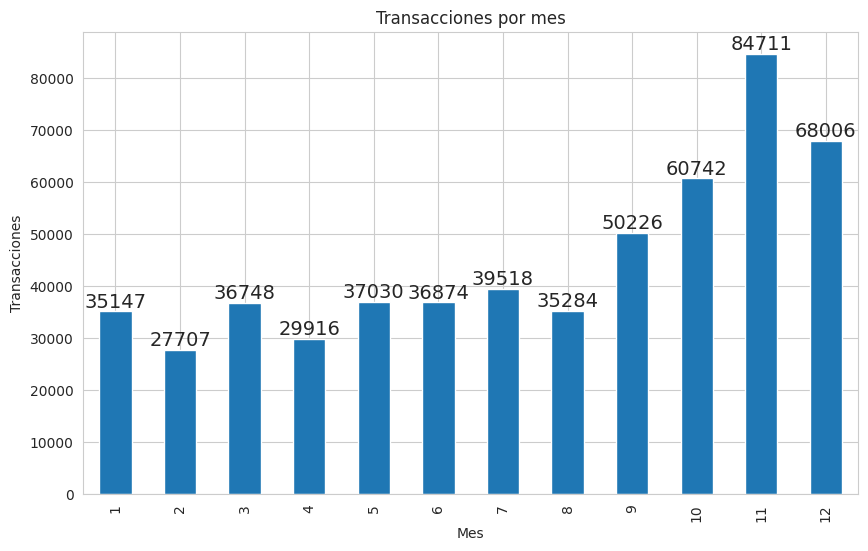

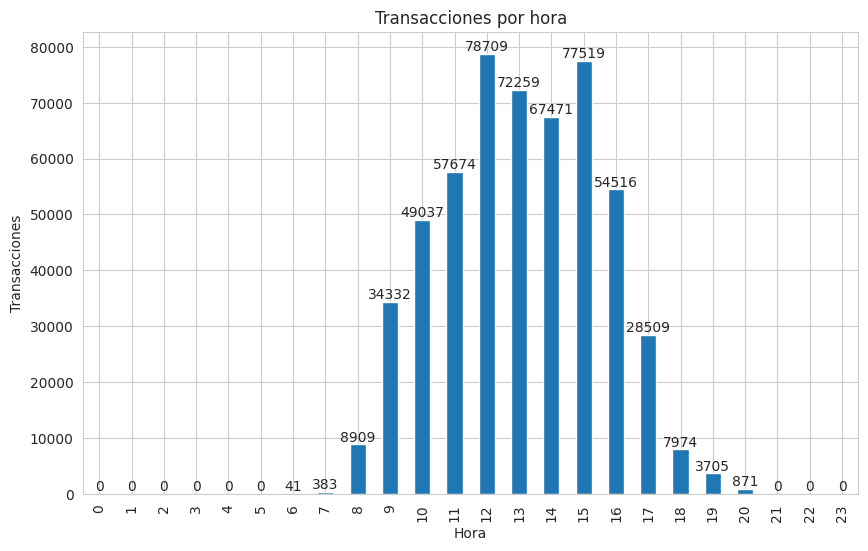

In [ ]:
#Creamos las diferentes columnas para invoiceDate(dia,mes,año y hora)
#Nos aseguramos que la columna de InvoiceDate es de tipo date y si no es asi parsearla
if(dfc['InvoiceDate'].dtype == 'object'):
  dfc['InvoiceDate'] = pd.to_datetime(dfc['InvoiceDate'])

display(dfc['InvoiceDate'].sample(5))

#Comprobamos que no tengamos datos Nat tras el parseo
print(f"Valores Nat tras parseo: {dfc['InvoiceDate'].isna().sum()}\n")

#Extraemos cada componente en una columna nueva

dfc["InvoiceDay"] = dfc["InvoiceDate"].dt.day
dfc["InvoiceMonth"] = dfc["InvoiceDate"].dt.month
dfc["InvoiceYear"] = dfc["InvoiceDate"].dt.year
dfc["InvoiceHour"] = dfc["InvoiceDate"].dt.hour

print("\n")

#Comprobamos si las fechas estan en el rango de ventas esperado por el dataset (2010/2011)
if(dfc['InvoiceYear'].min() == 2010 and dfc['InvoiceYear'].max() == 2011):
  print(f"Rango de fechas correcto: {dfc['InvoiceYear'].min()} - {dfc['InvoiceYear'].max()}")
else:
  print(f"Rango de fechas incorrecto: {dfc['InvoiceYear'].min()} - {dfc['InvoiceYear'].max()}")


#Comprobamos si las nuevas columnas tienen sentido
print(f"Dias unicos encontrados:{sorted(dfc['InvoiceDay'].unique().tolist())}")
print(f"Meses unicosencontrados:{sorted(dfc['InvoiceMonth'].unique().tolist())}")
print(f"Años unicos encontrados:{sorted(dfc['InvoiceYear'].unique().tolist())}")
print(f"Horas unicos encontradas:{sorted(dfc['InvoiceHour'].unique().tolist())}")

#Mostramos numero de transacciones por mes
transaciones_mes = dfc.groupby('InvoiceMonth').size()
transacciones_mes = transaciones_mes.reindex(range(1,13), fill_value=0)
ax = transaciones_mes.plot(kind='bar')
for m in ax.patches:
    ax.annotate(f'{m.get_height()}',
                (m.get_x() + m.get_width() / 2, m.get_height()),
                ha='center', va='bottom',
                size=14)
plt.xlabel('Mes')
plt.ylabel('Transacciones')
plt.title('Transacciones por mes')
plt.xticks(range(12),range(1,13))
plt.show()


# Reindexamos para incluir todas las horas de 0 a 23, rellenando con 0 las que no existen
# Calculamos los datos primero
ventas_por_hora = dfc.groupby('InvoiceHour').size()

# Reindexamos para incluir todas las horas de 0 a 23, rellenando con 0 las que no existen
ventas_por_hora = ventas_por_hora.reindex(range(24), fill_value=0)

#Grafico nuemero de ventas por franga horaria
ax = ventas_por_hora.plot(kind='bar')
plt.xlabel('Hora')
plt.ylabel('Transacciones')
plt.title('Transacciones por hora')

# Añadir el número encima de cada barra
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posición horizontal: centro de la barra
        bar.get_height(),                     # posición vertical: tope de la barra
        str(int(bar.get_height())),           # el texto: el valor de la barra
        ha='center', va='bottom'              # alineación: centrado y justo encima
    )

plt.show()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek
72296,542238,22922,FRIDGE MAGNETS US DINER ASSORTED,12,2011-01-26 14:35:00,0.85,"12,591.00",Italy,26,1,2011,14,2
207542,554993,21673,WHITE SPOT BLUE CERAMIC DRAWER KNOB,2,2011-05-29 14:13:00,1.25,"17,051.00",United Kingdom,29,5,2011,14,6
68516,541869,85132A,CHARLIE + LOLA BISCUITS TINS,1,2011-01-24 09:35:00,8.29,NaN,United Kingdom,24,1,2011,9,0
106161,545314,21749,LARGE RED RETROSPOT WINDMILL,6,2011-03-01 14:11:00,2.10,"12,866.00",Belgium,1,3,2011,14,1
483212,577497,22175,PINK OWL SOFT TOY,1,2011-11-20 12:22:00,2.95,"17,555.00",United Kingdom,20,11,2011,12,6


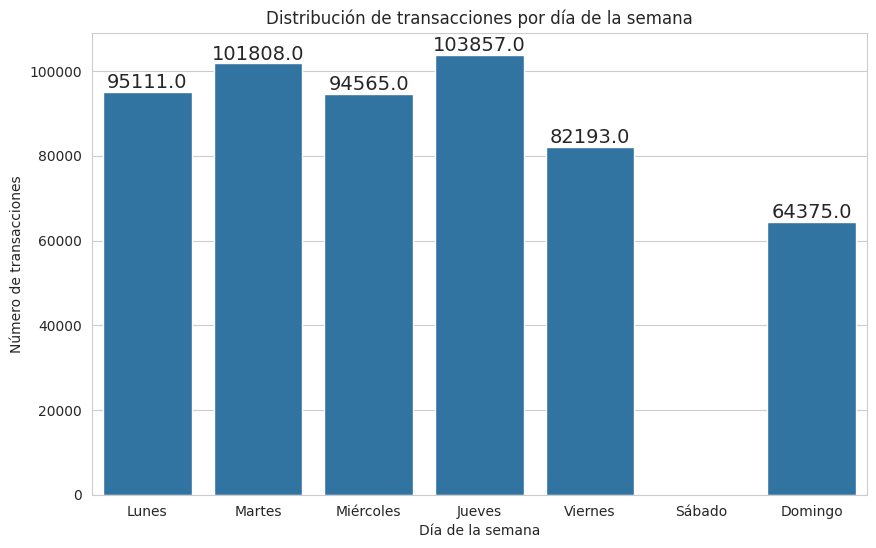

In [ ]:
#Añadimos una columna de dia de la semana 0 siendo lunes y 6 siendo domingo
dfc["DayOfWeek"] = dfc['InvoiceDate'].dt.weekday
display(dfc.sample(5))

#Mostramos el numero de transacciones por dia de4 la semana
ax = sns.countplot(data=dfc, x="DayOfWeek",order=range(7))
for day in ax.patches:
    ax.annotate(f'{day.get_height()}',
                (day.get_x() + day.get_width() / 2, day.get_height()),
                ha='center', va='bottom',
                size=14)
plt.xticks(range(7), ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'])
plt.title("Distribución de transacciones por día de la semana")
plt.ylabel("Número de transacciones")
plt.xlabel("Día de la semana")
plt.show()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk
456970,575726,82483,WOOD 2 DRAWER CABINET WHITE FINISH,1,2011-11-10 19:12:00,6.95,"16,791.00",United Kingdom,10,11,2011,19,3,1
126199,547067,21931,JUMBO STORAGE BAG SUKI,30,2011-03-20 13:43:00,1.95,"12,921.00",United Kingdom,20,3,2011,13,6,1
20426,538051,22133,PINK LOVE HEART SHAPE CUP,20,2010-12-09 13:24:00,0.85,"18,041.00",United Kingdom,9,12,2010,13,3,1
3005,536592,85150,LADIES & GENTLEMEN METAL SIGN,1,2010-12-01 17:06:00,5.06,NaN,United Kingdom,1,12,2010,17,2,1
305287,563662,22554,PLASTERS IN TIN WOODLAND ANIMALS,12,2011-08-18 11:40:00,1.65,"12,729.00",France,18,8,2011,11,3,0


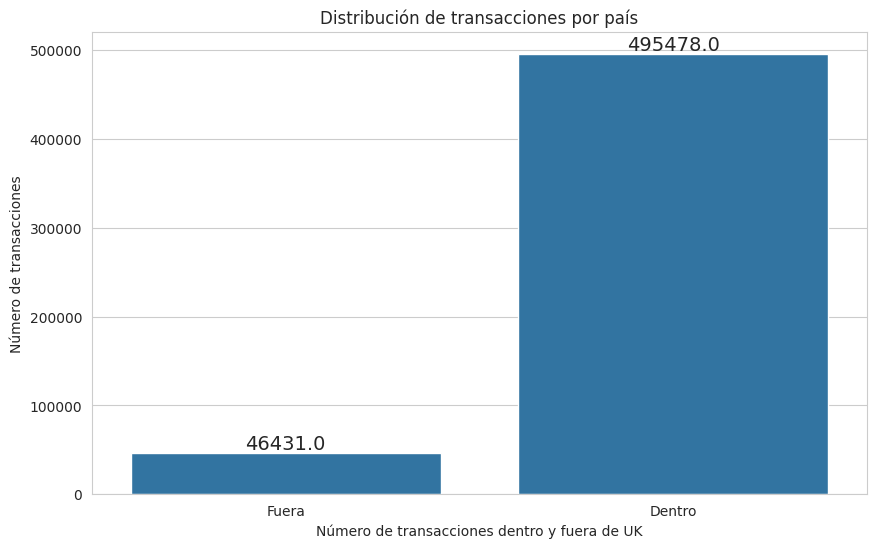

In [ ]:
#Creamos la columna binaria  de isUk donde 0 es false y 1 true
dfc["IsUk"] = np.where(dfc["Country"] == "United Kingdom", 1, 0)
display(dfc.sample(5))

#Mostramos numero de registros totales dentro y fuera de uk
ax = sns.countplot(data=dfc, x="IsUk")

for bar in ax.patches:
    ax.annotate(f'{bar.get_height()}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom',
                size=14)
plt.xticks([0, 1], ["Fuera", "Dentro"])
plt.title("Distribución de transacciones por país")
plt.ylabel("Número de transacciones")
plt.xlabel("Número de transacciones dentro y fuera de UK")
plt.show()

In [ ]:
#borramos duplicados en una primera fase ya que sabemos seguro que no nos sirven
print(f"Dimensiones del DataFrame antes de eliminar duplicados: {dfc.shape}")
dfc.drop_duplicates(inplace=True)
print(f"Dimensiones del DataFrame después de eliminar duplicados: {dfc.shape}")

#mostramos cuantas filas duplicadas se han borrado
print(f"Filas duplicadas borradas: {len(df) - len(dfc)}")

Dimensiones del DataFrame antes de eliminar duplicados: (541909, 14)
Dimensiones del DataFrame después de eliminar duplicados: (536641, 14)
Filas duplicadas borradas: 5268


In [ ]:
#a partir de ahora trabajarenos con la copia dfc del dataset limpio de duplicados
#Identificacion de valores nulos

null = dfc.isnull().sum()
porcentaje_null = (null / len(dfc)) * 100


#Mostramos
print("Valores nulos por columna:")
print(null)
print("\nPorcentaje de valores nulos por columna:")
print(porcentaje_null)

#tabla

df_nulos = pd.DataFrame({
    "Nulos": null,
    "Porcentaje (%)": porcentaje_null.round(2)
})

df_nulos = df_nulos[df_nulos["Nulos"] > 0]
df_nulos = df_nulos.sort_values(by="Nulos", ascending=False)

if not df_nulos.empty:
    print("Columnas con valores nulos (conteo y porcentaje):")
    display(df_nulos)
else:
    print("No se encontraron valores nulos en el DataFrame.")

total_columnas_con_nulos = df_nulos.shape[0]

print(f"\nTotal de columnas con valores nulos: {total_columnas_con_nulos}")


Valores nulos por columna:
InvoiceNo            0
StockCode            0
Description       1454
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID      135037
Country              0
InvoiceDay           0
InvoiceMonth         0
InvoiceYear          0
InvoiceHour          0
DayOfWeek            0
IsUk                 0
dtype: int64

Porcentaje de valores nulos por columna:
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     25.16
Country         0.00
InvoiceDay      0.00
InvoiceMonth    0.00
InvoiceYear     0.00
InvoiceHour     0.00
DayOfWeek       0.00
IsUk            0.00
dtype: float64
Columnas con valores nulos (conteo y porcentaje):


,Nulos,Porcentaje (%)
CustomerID,135037,25.16
Description,1454,0.27



Total de columnas con valores nulos: 2


In [ ]:
#mostrar todos los nulos de CustomerID
nulos_customer_id = dfc[dfc['CustomerID'].isnull()]
print(f"Número de registros con CustomerID nulo: {len(nulos_customer_id)}")
display(nulos_customer_id)

Número de registros con CustomerID nulo: 135037


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,1,12,2010,11,2,1
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom,1,12,2010,14,2,1
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,1,12,2010,14,2,1
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom,1,12,2010,14,2,1
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom,1,12,2010,14,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom,9,12,2011,10,4,1
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom,9,12,2011,10,4,1
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom,9,12,2011,10,4,1
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom,9,12,2011,10,4,1


In [ ]:
#borrar nulos con mas de tres columnas nulas o cero

In [ ]:
# ==============================
# ANÁLISIS DE FILAS ANÓMALAS
# ==============================

# 1) Máscaras base
A = dfc['UnitPrice'] == 0
B = dfc['Quantity'] <= 0
C = dfc['CustomerID'].isnull()
D = dfc['Description'].isnull()

# 2) Tres opciones de filtrado
mask1 = (A & B) | (C & D)
mask2 = A & B & C & D
mask3 = A | (B & C & D)

# 3) Mostrar cuántas filas devuelve cada opción
print("RESULTADOS DE LAS 3 OPCIONES")
print(f"Opción 1 -> ((UnitPrice == 0) y (Quantity <= 0)) o ((CustomerID nulo) y (Description nula)): {mask1.sum()}")
print(f"Opción 2 -> (UnitPrice == 0) y (Quantity <= 0) y (CustomerID nulo) y (Description nula): {mask2.sum()}")
print(f"Opción 3 -> (UnitPrice == 0) o ((Quantity <= 0) y (CustomerID nulo) y (Description nula)): {mask3.sum()}")

# 4) Elegir qué opción analizar
# Cambia aquí: "opcion1", "opcion2" o "opcion3"
modo_analisis = "opcion3"

if modo_analisis == "opcion1":
    condiciones_especificas = mask1
    descripcion_modo = "((UnitPrice == 0) y (Quantity <= 0)) o ((CustomerID nulo) y (Description nula))"
elif modo_analisis == "opcion2":
    condiciones_especificas = mask2
    descripcion_modo = "(UnitPrice == 0) y (Quantity <= 0) y (CustomerID nulo) y (Description nula)"
elif modo_analisis == "opcion3":
    condiciones_especificas = mask3
    descripcion_modo = "(UnitPrice == 0) o ((Quantity <= 0) y (CustomerID nulo) y (Description nula))"
else:
    raise ValueError("modo_analisis debe ser: 'opcion1', 'opcion2' o 'opcion3'")

# 5) Subconjunto filtrado
filas_caso_especifico = dfc[condiciones_especificas].copy()

print("\n" + "="*70)
print(f"MODO DE ANÁLISIS SELECCIONADO: {modo_analisis}")
print(f"Lógica aplicada: {descripcion_modo}")
print(f"Número de registros encontrados: {len(filas_caso_especifico)}")

if filas_caso_especifico.empty:
    print("No se encontraron filas que cumplan con las condiciones específicas.")
else:
    # 6) Crear banderas de anomalía dentro del subconjunto filtrado
    filas_caso_especifico['anomalia_unitprice_0'] = filas_caso_especifico['UnitPrice'] == 0
    filas_caso_especifico['anomalia_quantity_le_0'] = filas_caso_especifico['Quantity'] <= 0
    filas_caso_especifico['anomalia_quantity_lt_0'] = filas_caso_especifico['Quantity'] < 0
    filas_caso_especifico['anomalia_quantity_eq_0'] = filas_caso_especifico['Quantity'] == 0
    filas_caso_especifico['anomalia_customerid_nulo'] = filas_caso_especifico['CustomerID'].isnull()
    filas_caso_especifico['anomalia_description_nula'] = filas_caso_especifico['Description'].isnull()

    # 7) Etiqueta exacta de combinación de anomalías
    def etiquetar_fila(row):
        etiquetas = []
        if row['anomalia_unitprice_0']:
            etiquetas.append("UnitPrice=0")
        if row['anomalia_quantity_le_0']:
            etiquetas.append("Quantity<=0")
        if row['anomalia_customerid_nulo']:
            etiquetas.append("CustomerID nulo")
        if row['anomalia_description_nula']:
            etiquetas.append("Description nula")
        return " + ".join(etiquetas) if etiquetas else "Sin anomalía"

    filas_caso_especifico['tipo_anomalia'] = filas_caso_especifico.apply(etiquetar_fila, axis=1)

    # 8) Resumen individual por anomalía
    resumen_individual = pd.DataFrame({
        'Métrica': [
            'Total filas filtradas',
            'UnitPrice = 0',
            'Quantity <= 0',
            'Quantity < 0 (devoluciones o ajustes)',
            'Quantity = 0',
            'CustomerID nulo',
            'Description nula',
            'UnitPrice = 0 y Quantity <= 0',
            'CustomerID nulo y Description nula',
            'Las 4 condiciones a la vez'
        ],
        'Cantidad': [
            len(filas_caso_especifico),
            filas_caso_especifico['anomalia_unitprice_0'].sum(),
            filas_caso_especifico['anomalia_quantity_le_0'].sum(),
            filas_caso_especifico['anomalia_quantity_lt_0'].sum(),
            filas_caso_especifico['anomalia_quantity_eq_0'].sum(),
            filas_caso_especifico['anomalia_customerid_nulo'].sum(),
            filas_caso_especifico['anomalia_description_nula'].sum(),
            (filas_caso_especifico['anomalia_unitprice_0'] & filas_caso_especifico['anomalia_quantity_le_0']).sum(),
            (filas_caso_especifico['anomalia_customerid_nulo'] & filas_caso_especifico['anomalia_description_nula']).sum(),
            (
                filas_caso_especifico['anomalia_unitprice_0'] &
                filas_caso_especifico['anomalia_quantity_le_0'] &
                filas_caso_especifico['anomalia_customerid_nulo'] &
                filas_caso_especifico['anomalia_description_nula']
            ).sum()
        ]
    })

    # 9) Resumen por combinaciones exactas
    resumen_combinaciones = (
        filas_caso_especifico['tipo_anomalia']
        .value_counts(dropna=False)
        .reset_index()
    )
    resumen_combinaciones.columns = ['Combinación exacta de anomalías', 'Cantidad']

    # 10) Mostrar resultados
    print("\nRESUMEN INDIVIDUAL DE ANOMALÍAS")
    display(resumen_individual)

    print("\nRESUMEN POR COMBINACIONES EXACTAS")
    display(resumen_combinaciones)

    print("\nPRIMERAS 20 FILAS DETECTADAS")
    display(
        filas_caso_especifico[
            [
                'InvoiceNo', 'StockCode', 'Description', 'Quantity',
                'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country',
                'tipo_anomalia'
            ]
        ].head(20)
    )

RESULTADOS DE LAS 3 OPCIONES
Opción 1 -> ((UnitPrice == 0) y (Quantity <= 0)) o ((CustomerID nulo) y (Description nula)): 1928
Opción 2 -> (UnitPrice == 0) y (Quantity <= 0) y (CustomerID nulo) y (Description nula): 862
Opción 3 -> (UnitPrice == 0) o ((Quantity <= 0) y (CustomerID nulo) y (Description nula)): 2510

MODO DE ANÁLISIS SELECCIONADO: opcion3
Lógica aplicada: (UnitPrice == 0) o ((Quantity <= 0) y (CustomerID nulo) y (Description nula))
Número de registros encontrados: 2510

RESUMEN INDIVIDUAL DE ANOMALÍAS


,Métrica,Cantidad
0,Total filas filtradas,2510
1,UnitPrice = 0,2510
2,Quantity <= 0,1336
3,Quantity < 0 (devoluciones o ajustes),1336
4,Quantity = 0,0
5,CustomerID nulo,2470
6,Description nula,1454
7,UnitPrice = 0 y Quantity <= 0,1336
8,CustomerID nulo y Description nula,1454
9,Las 4 condiciones a la vez,862



RESUMEN POR COMBINACIONES EXACTAS


,Combinación exacta de anomalías,Cantidad
0,UnitPrice=0 + Quantity<=0 + CustomerID nulo + ...,862
1,UnitPrice=0 + CustomerID nulo + Description nula,592
2,UnitPrice=0 + CustomerID nulo,542
3,UnitPrice=0 + Quantity<=0 + CustomerID nulo,474
4,UnitPrice=0,40



PRIMERAS 20 FILAS DETECTADAS


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,tipo_anomalia
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,UnitPrice=0 + CustomerID nulo + Description nula
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.00,NaN,United Kingdom,UnitPrice=0 + CustomerID nulo + Description nula
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom,UnitPrice=0 + CustomerID nulo + Description nula
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom,UnitPrice=0 + CustomerID nulo + Description nula
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom,UnitPrice=0 + CustomerID nulo + Description nula
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom,UnitPrice=0 + CustomerID nulo + Description nula
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom,UnitPrice=0 + CustomerID nulo + Description nula
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.00,NaN,United Kingdom,UnitPrice=0 + CustomerID nulo + Description nula
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.00,NaN,United Kingdom,UnitPrice=0 + CustomerID nulo + Description nula
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.00,NaN,United Kingdom,UnitPrice=0 + Quantity<=0 + CustomerID nulo + ...


In [ ]:
#borra todas las filas que cumplen la condicion 3 precio 0 o cantidad cero y customerid null y descripcion null
#Opción 3 -> (UnitPrice == 0) o ((Quantity <= 0) y (CustomerID nulo) y (Description nula)): 2510

condiciones_especificas = (dfc['UnitPrice'] == 0) | (
    (dfc['Quantity'] <= 0) &
    (dfc['CustomerID'].isnull()) &
    (dfc['Description'].isnull())
)

dfc = dfc[~condiciones_especificas].copy()

print(f"Filas restantes: {len(dfc)}")



Filas restantes: 534131


In [ ]:
#muestra las primeras 20 filas del dataset
dfc.head(20)

#muestra las filas con IsUk == 0
dfc[dfc['IsUk'] == 0].head(20)


In [ ]:
print(f"Filas dataset limpio: {len(dfc)}")
print(f"Filas original: {len(df)}")
print(f'Filas borradas tras aplicar la regla 3 y la eliminacion de duplicados: {len(df) - len(dfc)}')


Filas dataset limpio: 534131
Filas original: 541909
Filas borradas tras aplicar la regla 3 y la eliminacion de duplicados: 7778


In [ ]:
#imprime todas las filas de dfc donde Quantity es menor que 0
filas_negativas = dfc[dfc['Quantity'] < 0]
print(f"Número de filas con Quantity < 0: {len(filas_negativas)}")

Número de filas con Quantity < 0: 9251


In [ ]:
# ============================================================
# FILAS CON VALORES MÁS ALTOS Y MÁS BAJOS
# ============================================================
dfc['TotalPrice'] = dfc['Quantity'] * dfc['UnitPrice']

columnas_mostrar = [
    'InvoiceNo', 'StockCode', 'Description', 'Quantity',
    'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'
]

for col in ['Quantity', 'UnitPrice', 'TotalPrice']:
    print(f"\n{'='*80}")
    print(f"TOP 20 VALORES MÁS ALTOS EN {col}")
    print(f"{'='*80}")
    display(dfc.nlargest(20, col)[columnas_mostrar])

    print(f"\n{'='*80}")
    print(f"TOP 20 VALORES MÁS BAJOS EN {col}")
    print(f"{'='*80}")
    display(dfc.nsmallest(20, col)[columnas_mostrar])


TOP 20 VALORES MÁS ALTOS EN Quantity


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,"16,446.00",United Kingdom,"168,469.60"
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,"12,346.00",United Kingdom,"77,183.60"
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,"12,901.00",United Kingdom,"1,008.00"
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,"13,135.00",United Kingdom,"3,096.00"
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,"18,087.00",United Kingdom,"3,202.92"
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,"14,609.00",United Kingdom,191.16
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,"15,749.00",United Kingdom,"6,539.40"
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,"15,749.00",United Kingdom,"6,539.40"
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,2011-11-02 11:24:00,0.32,"16,308.00",United Kingdom,960.00
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,2010-12-02 17:38:00,0.18,"16,754.00",United Kingdom,518.40



TOP 20 VALORES MÁS BAJOS EN Quantity


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,"16,446.00",United Kingdom,"-168,469.60"
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,"12,346.00",United Kingdom,"-77,183.60"
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,"15,838.00",United Kingdom,-280.80
160145,C550456,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,-3114,2011-04-18 13:08:00,2.10,"15,749.00",United Kingdom,"-6,539.40"
160144,C550456,21175,GIN + TONIC DIET METAL SIGN,-2000,2011-04-18 13:08:00,1.85,"15,749.00",United Kingdom,"-3,700.00"
160143,C550456,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-1930,2011-04-18 13:08:00,2.55,"15,749.00",United Kingdom,"-4,921.50"
224419,C556522,22920,HERB MARKER BASIL,-1515,2011-06-13 11:21:00,0.55,"16,938.00",United Kingdom,-833.25
187609,C552995,M,Manual,-1350,2011-05-12 15:19:00,0.16,"18,133.00",United Kingdom,-216.00
160142,C550456,47566B,TEA TIME PARTY BUNTING,-1300,2011-04-18 13:08:00,2.55,"15,749.00",United Kingdom,"-3,315.00"
390544,C570556,20971,PINK BLUE FELT CRAFT TRINKET BOX,-1296,2011-10-11 11:10:00,1.06,"16,029.00",United Kingdom,"-1,373.76"



TOP 20 VALORES MÁS ALTOS EN UnitPrice


...

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,"-11,062.06",NaN,United Kingdom,"-11,062.06"
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,"-11,062.06",NaN,United Kingdom,"-11,062.06"
157195,550193,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-04-15 09:27:00,0.00,"13,952.00",United Kingdom,0.00
279045,561226,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-07-26 10:13:00,0.00,"15,618.00",United Kingdom,0.00
359871,568200,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-09-25 14:58:00,0.00,"16,198.00",United Kingdom,0.00
361741,568375,BANK CHARGES,Bank Charges,1,2011-09-26 17:01:00,0.00,"13,405.00",United Kingdom,0.00
108088,C545478,D,Discount,-720,2011-03-03 11:08:00,0.01,"16,422.00",United Kingdom,-7.20
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,"15,838.00",United Kingdom,-280.80
182729,C552569,D,Discount,-240,2011-05-10 12:06:00,0.03,"12,901.00",United Kingdom,-7.20
355050,C567903,M,Manual,-120,2011-09-22 16:29:00,0.03,"16,422.00",United Kingdom,-3.60



TOP 20 VALORES MÁS ALTOS EN TotalPrice


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,"16,446.00",United Kingdom,"168,469.60"
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,"12,346.00",United Kingdom,"77,183.60"
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,"15,098.00",United Kingdom,"38,970.00"
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,"13,541.33",NaN,United Kingdom,"13,541.33"
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,"11,062.06",NaN,United Kingdom,"11,062.06"
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,"8,142.75","16,029.00",United Kingdom,"8,142.75"
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,"17,450.00",United Kingdom,"7,144.72"
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,"15,749.00",United Kingdom,"6,539.40"
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,"15,749.00",United Kingdom,"6,539.40"
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,"14,646.00",Netherlands,"4,992.00"



TOP 20 VALORES MÁS BAJOS EN TotalPrice


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,"16,446.00",United Kingdom,"-168,469.60"
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,"12,346.00",United Kingdom,"-77,183.60"
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,"38,970.00","15,098.00",United Kingdom,"-38,970.00"
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,"17,836.46",NaN,United Kingdom,"-17,836.46"
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,"16,888.02",NaN,United Kingdom,"-16,888.02"
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,"16,453.71",NaN,United Kingdom,"-16,453.71"
15016,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,"13,541.33",NaN,United Kingdom,"-13,541.33"
16356,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,"13,541.33",NaN,United Kingdom,"-13,541.33"
16232,C537644,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:34:00,"13,474.79",NaN,United Kingdom,"-13,474.79"
524601,C580604,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:35:00,"11,586.50",NaN,United Kingdom,"-11,586.50"


In [ ]:
# ============================================================
# DETECTAR Y ELIMINAR PARES DE CORRECCIÓN / REVERSIÓN
# ------------------------------------------------------------
# Criterio:
# - una fila positiva
# - otra negativa posterior
# - mismo StockCode, Description, UnitPrice, CustomerID, Country
# - misma cantidad en valor absoluto
# - dentro de una ventana temporal configurable
# ============================================================

import pandas as pd
import numpy as np

# -------- PARÁMETRO AJUSTABLE ----------
VENTANA_HORAS = 12  # cambia a 24, 12, 72... según quieras ser más estricto o más flexible
# --------------------------------------

tmp = dfc.copy()

# Guardar índice original para poder borrar después
tmp['idx_original'] = tmp.index

# Asegurar formato datetime
tmp['InvoiceDate'] = pd.to_datetime(tmp['InvoiceDate'], errors='coerce')

# Normalización de claves para emparejar mejor
tmp['StockCode_norm'] = tmp['StockCode'].astype(str).str.strip().str.upper()
tmp['Description_norm'] = tmp['Description'].fillna('').astype(str).str.strip().str.upper()
tmp['Country_norm'] = tmp['Country'].fillna('').astype(str).str.strip().str.upper()

# CustomerID: permitir emparejar también nulos
tmp['CustomerID_norm'] = tmp['CustomerID'].astype(str).replace('nan', '__NULL__')

# Redondeo por seguridad en precios
tmp['UnitPrice_norm'] = tmp['UnitPrice'].round(2)

# Cantidad absoluta
tmp['abs_qty'] = tmp['Quantity'].abs()

# Separar positivos y negativos
pos = tmp[tmp['Quantity'] > 0].copy()
neg = tmp[tmp['Quantity'] < 0].copy()

# Renombrar para merge
pos = pos.rename(columns={
    'idx_original': 'idx_pos',
    'InvoiceDate': 'InvoiceDate_pos',
    'Quantity': 'Quantity_pos',
    'InvoiceNo': 'InvoiceNo_pos'
})

neg = neg.rename(columns={
    'idx_original': 'idx_neg',
    'InvoiceDate': 'InvoiceDate_neg',
    'Quantity': 'Quantity_neg',
    'InvoiceNo': 'InvoiceNo_neg'
})

# Claves de emparejamiento
keys = [
    'StockCode_norm',
    'Description_norm',
    'UnitPrice_norm',
    'CustomerID_norm',
    'Country_norm',
    'abs_qty'
]

# Cruce candidatos
candidatos = pos.merge(
    neg,
    on=keys,
    how='inner',
    suffixes=('_pos', '_neg')
)

# Quedarnos solo con negativos posteriores y dentro de ventana
candidatos = candidatos[
    (candidatos['InvoiceDate_neg'] > candidatos['InvoiceDate_pos']) &
    ((candidatos['InvoiceDate_neg'] - candidatos['InvoiceDate_pos']) <= pd.Timedelta(hours=VENTANA_HORAS))
].copy()

# Diferencia temporal
candidatos['delta_tiempo'] = candidatos['InvoiceDate_neg'] - candidatos['InvoiceDate_pos']

# Ordenar por cercanía temporal
candidatos = candidatos.sort_values(['idx_pos', 'delta_tiempo', 'idx_neg'])

# Emparejamiento 1 a 1:
# 1) primer negativo más cercano para cada positivo
pares = candidatos.drop_duplicates(subset='idx_pos', keep='first').copy()

# 2) asegurar que un mismo negativo no se use dos veces
pares = pares.sort_values(['idx_neg', 'delta_tiempo']).drop_duplicates(subset='idx_neg', keep='first').copy()

# Orden final
pares = pares.sort_values(['InvoiceDate_pos', 'InvoiceDate_neg']).copy()

# Resumen de pares detectados
columnas_resumen = [
    'idx_pos', 'InvoiceNo_pos', 'idx_neg', 'InvoiceNo_neg',
    'StockCode_norm', 'Description_norm',
    'Quantity_pos', 'Quantity_neg',
    'UnitPrice_norm', 'CustomerID_norm', 'Country_norm',
    'InvoiceDate_pos', 'InvoiceDate_neg', 'delta_tiempo'
]

resumen_pares = pares[columnas_resumen].copy()

print("==============================================")
print("ANÁLISIS DE PARES DE CORRECCIÓN / REVERSIÓN")
print("==============================================")
print(f"Ventana temporal usada: {VENTANA_HORAS} horas")
print(f"Pares detectados: {len(resumen_pares)}")
print(f"Filas que se eliminarán: {len(resumen_pares) * 2}")

display(resumen_pares.head(30))

# Índices a eliminar
indices_borrar = pd.Index(pares['idx_pos']).append(pd.Index(pares['idx_neg'])).unique()

# Crear dataset limpio
dfc = dfc.drop(index=indices_borrar, errors='ignore').copy()

print("\n==============================================")
print("LIMPIEZA APLICADA")
print("==============================================")
print(f"Índices eliminados: {len(indices_borrar)}")
print(f"Filas restantes en dfc: {len(dfc)}")

#comaprar df con dfc y ver cuantas lineas se han eliminado
print(f"Filas borradas tras aplicar la regla 4: {len(df) - len(dfc)}")


ANÁLISIS DE PARES DE CORRECCIÓN / REVERSIÓN
Ventana temporal usada: 12 horas
Pares detectados: 1
Filas que se eliminarán: 2


,idx_pos,InvoiceNo_pos,idx_neg,InvoiceNo_neg,StockCode_norm,Description_norm,Quantity_pos,Quantity_neg,UnitPrice_norm,CustomerID_norm,Country_norm,InvoiceDate_pos,InvoiceDate_neg,delta_tiempo
3854,393763,570848,393786,C570854,22086,PAPER CHAIN KIT 50'S CHRISTMAS,40,-40,2.55,15473.0,UNITED KINGDOM,2011-10-12 14:42:00,2011-10-12 14:55:00,0 days 00:13:00



LIMPIEZA APLICADA
Índices eliminados: 2
Filas restantes en dfc: 532937
Filas borradas tras aplicar la regla 4: 8972


In [ ]:
# ============================================================
# REGRESIÓN: conservar solo ventas positivas
# ------------------------------------------------------------
# Se excluyen devoluciones y notas de crédito para construir
# un dataset orientado a ventas brutas diarias.
# CustomerID nulo se conserva para regresión.
# ============================================================

mask_devoluciones = (
    (dfc['Quantity'] < 0) |
    (dfc['InvoiceNo'].astype(str).str.startswith('C', na=False))
)

print(f"Filas a eliminar (devoluciones / credit notes): {mask_devoluciones.sum()}")

dfc = dfc[~mask_devoluciones].copy()

print(f"Filas restantes en dataset para regresión bruta: {len(dfc)}")
print(f"Filas borradas acumuladas respecto al original: {len(df) - len(dfc)}")

Filas a eliminar (devoluciones / credit notes): 8654
Filas restantes en dataset para regresión bruta: 524283
Filas borradas acumuladas respecto al original: 17626


In [ ]:
#imprime todas las filas de dfc donde Quantity es menor que 0
filas_negativas = dfc[dfc['Quantity'] < 0]
print(f"Número de filas con Quantity < 0: {len(filas_negativas)}")

Número de filas con Quantity < 0: 0


In [ ]:
# ============================================================
# REVISIÓN Y ELIMINACIÓN DE LÍNEAS NO ASOCIADAS A PRODUCTO REAL
# ============================================================

descripciones_excluir = [
    'POSTAGE',
    'DOTCOM POSTAGE',
    'MANUAL',
    'CARRIAGE',
    'AMAZON FEE',
    'ADJUST BAD DEBT',
    'BANK CHARGES',
    'DISCOUNT',
    'SAMPLES',
    'CRUK COMMISSION'
]

desc_norm = dfc['Description'].astype(str).str.strip().str.upper()
mask_no_producto = desc_norm.isin(descripciones_excluir)

print("Conteo por descripción antes de eliminar:")
display(desc_norm[mask_no_producto].value_counts())

print(f"\nFilas a eliminar: {mask_no_producto.sum()}")

dfc = dfc[~mask_no_producto].copy()

print(f"Filas restantes: {len(dfc)}")
print(f"Filas borradas: {len(df) - len(dfc)}")

Conteo por descripción antes de eliminar:


,count
Description,
POSTAGE,1120
DOTCOM POSTAGE,706
MANUAL,289
CARRIAGE,141
BANK CHARGES,12
ADJUST BAD DEBT,3
SAMPLES,2



Filas a eliminar: 2273
Filas restantes: 522010
Filas borradas: 19899


In [ ]:
# Identificar filas con Quantity <= 0 en el DataFrame limpio (dfc)
print("\n--- Filas con 'Quantity' menor o igual a cero en dfc ---")
quantity_no_positiva_dfc = dfc[dfc['Quantity'] <= 0]
print(f"Número de registros con Quantity <= 0 en dfc: {len(quantity_no_positiva_dfc)}")
if not quantity_no_positiva_dfc.empty:
    print("Se encontraron los siguientes registros anómalos:")
    display(quantity_no_positiva_dfc)
else:
    print("No se encontraron filas con 'Quantity' menor o igual a cero en dfc.")

# Identificar filas con UnitPrice <= 0 en el DataFrame limpio (dfc)
print("\n--- Filas con 'UnitPrice' menor o igual a cero en dfc ---")
unitprice_no_positivo_dfc = dfc[dfc['UnitPrice'] <= 0]
print(f"Número de registros con UnitPrice <= 0 en dfc: {len(unitprice_no_positivo_dfc)}")
if not unitprice_no_positivo_dfc.empty:
    print("Se encontraron los siguientes registros anómalos:")
    display(unitprice_no_positivo_dfc)
else:
    print("No se encontraron filas con 'UnitPrice' menor o igual a cero en dfc.")


--- Filas con 'Quantity' menor o igual a cero en dfc ---
Número de registros con Quantity <= 0 en dfc: 0
No se encontraron filas con 'Quantity' menor o igual a cero en dfc.

--- Filas con 'UnitPrice' menor o igual a cero en dfc ---
Número de registros con UnitPrice <= 0 en dfc: 0
No se encontraron filas con 'UnitPrice' menor o igual a cero en dfc.


In [ ]:
dfc.to_csv("data_v07_con_fechas_regresion_ventas.csv", index=False)

from google.colab import files
files.download("data_v07_con_fechas_regresion_ventas.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
dfc.head()

#muestra las 10 filas primeras aleatorias
dfc.sample(10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
164382,550638,85059,FRENCH ENAMEL WATER BASIN,1,2011-04-19 15:44:00,7.46,NaN,United Kingdom,19,4,2011,15,1,1,7.46
422582,573096,23355,HOT WATER BOTTLE KEEP CALM,4,2011-10-27 14:40:00,4.95,"14,004.00",United Kingdom,27,10,2011,14,3,1,19.80
156134,550121,22464,HANGING METAL HEART LANTERN,12,2011-04-14 12:38:00,1.65,"15,271.00",United Kingdom,14,4,2011,12,3,1,19.80
182522,552554,21901,"KEY FOB , BACK DOOR",10,2011-05-10 11:04:00,0.65,"12,843.00",United Kingdom,10,5,2011,11,1,1,6.50
33886,539305,85049E,SCANDINAVIAN REDS RIBBONS,12,2010-12-16 17:37:00,1.25,"14,334.00",United Kingdom,16,12,2010,17,3,1,15.00
480506,577308,23077,DOUGHNUT LIP GLOSS,20,2011-11-18 13:14:00,1.25,"15,088.00",United Kingdom,18,11,2011,13,4,1,25.00
307761,563927,21078,SET/20 STRAWBERRY PAPER NAPKINS,12,2011-08-21 15:01:00,0.85,"14,013.00",United Kingdom,21,8,2011,15,6,1,10.20
237420,557858,20719,WOODLAND CHARLOTTE BAG,2,2011-06-23 11:51:00,0.85,"14,159.00",United Kingdom,23,6,2011,11,3,1,1.70
472539,576689,23100,SILVER BELLS TABLE DECORATION,12,2011-11-16 12:18:00,1.25,"16,657.00",United Kingdom,16,11,2011,12,2,1,15.00
289487,562264,20981,12 PENCILS TALL TUBE WOODLAND,2,2011-08-03 16:14:00,1.63,NaN,United Kingdom,3,8,2011,16,2,1,3.26


In [ ]:
# ============================================================
# FUNCIONES COMUNES PARA OUTLIERS + LOG1P + ROBUSTSCALER
# Ejecutar una sola vez
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from IPython.display import display

def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

def resumen_outliers_iqr(df, columnas):
    resumen = []

    for col in columnas:
        if col not in df.columns:
            continue

        serie = df[col].dropna()
        if serie.empty:
            continue

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1

        li = q1 - 1.5 * iqr
        ls = q3 + 1.5 * iqr

        mask = (df[col] < li) | (df[col] > ls)
        n_outliers = int(mask.sum())
        pct_outliers = round((n_outliers / len(df)) * 100, 2)

        resumen.append({
            "columna": col,
            "Q1": round(q1, 4),
            "Q3": round(q3, 4),
            "IQR": round(iqr, 4),
            "limite_inferior": round(li, 4),
            "limite_superior": round(ls, 4),
            "n_outliers": n_outliers,
            "pct_outliers": pct_outliers,
            "min_real": round(serie.min(), 4),
            "max_real": round(serie.max(), 4)
        })

    return pd.DataFrame(resumen).sort_values(by="pct_outliers", ascending=False).reset_index(drop=True)

columnas_tratar = ["Quantity", "UnitPrice", "TotalPrice"]

outliers_ventas = resumen_outliers_iqr(dfc, columnas_tratar)
display(outliers_ventas)


,columna,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers,min_real,max_real
0,TotalPrice,3.90,17.70,13.80,-16.80,38.40,40948,7.84,0.00,"38,970.00"
1,UnitPrice,1.25,4.13,2.88,-3.07,8.45,35725,6.84,0.00,649.50
2,Quantity,1.00,12.00,11.00,-15.50,28.50,26673,5.11,1.00,"4,800.00"


In [ ]:
# ============================================================
# TRATAMIENTO DE OUTLIERS CON CRITERIO
# DATASET POSITIVO: ventas o clustering
# - analiza outliers
# - NO los elimina automáticamente
# - aplica log1p
# - aplica RobustScaler
# - trabaja sobre una copia
# ============================================================

columnas_tratar = ["Quantity", "UnitPrice", "TotalPrice"]

# 1) Copia de trabajo para no modificar el dataset original
dfc_modelo = dfc.copy()

# 2) Resumen de outliers antes del tratamiento
print("=" * 80)
print("RESUMEN DE OUTLIERS ANTES DEL TRATAMIENTO")
print("=" * 80)

outliers_antes = resumen_outliers_iqr(dfc_modelo, columnas_tratar)
display(outliers_antes)

# 3) Marcar outliers por columna (sin borrar filas)
for col in columnas_tratar:
    q1 = dfc_modelo[col].quantile(0.25)
    q3 = dfc_modelo[col].quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr

    dfc_modelo[f"{col}_outlier_iqr"] = ((dfc_modelo[col] < li) | (dfc_modelo[col] > ls)).astype(int)

# 4) Transformación logarítmica
# Se aplica porque reduce asimetría y comprime extremos altos
for col in columnas_tratar:
    dfc_modelo[f"{col}_log"] = np.log1p(dfc_modelo[col])

# 5) Escalado robusto sobre las columnas transformadas
# RobustScaler usa mediana e IQR, por eso resiste mejor los extremos
columnas_log = [f"{col}_log" for col in columnas_tratar]

scaler = RobustScaler()
dfc_modelo[[f"{col}_log_robust" for col in columnas_tratar]] = scaler.fit_transform(dfc_modelo[columnas_log])

# 6) Resumen estadístico final de las variables tratadas
print("\n" + "=" * 80)
print("RESUMEN FINAL DE VARIABLES TRANSFORMADAS")
print("=" * 80)

display(
    dfc_modelo[
        columnas_tratar +
        [f"{col}_log" for col in columnas_tratar] +
        [f"{col}_log_robust" for col in columnas_tratar]
    ].describe().T
)

# 7) Conteo de outliers marcados
print("\n" + "=" * 80)
print("CONTEO DE OUTLIERS MARCADOS")
print("=" * 80)

for col in columnas_tratar:
    n = dfc_modelo[f"{col}_outlier_iqr"].sum()
    pct = round(n / len(dfc_modelo) * 100, 2)
    print(f"{col}: {n} outliers ({pct}%)")

print("\nColumnas nuevas creadas:")
print([col for col in dfc_modelo.columns if col.endswith("_outlier_iqr") or col.endswith("_log") or col.endswith("_log_robust")])

print(dfc_modelo.head)

RESUMEN DE OUTLIERS ANTES DEL TRATAMIENTO


,columna,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers,min_real,max_real
0,TotalPrice,3.90,17.70,13.80,-16.80,38.40,40948,7.84,0.00,"38,970.00"
1,UnitPrice,1.25,4.13,2.88,-3.07,8.45,35725,6.84,0.00,649.50
2,Quantity,1.00,12.00,11.00,-15.50,28.50,26673,5.11,1.00,"4,800.00"



RESUMEN FINAL DE VARIABLES TRANSFORMADAS


,count,mean,std,min,25%,50%,75%,max
Quantity,"522,011.00",10.32,37.81,1.00,1.00,4.00,12.00,"4,800.00"
UnitPrice,"522,011.00",3.27,4.38,0.00,1.25,2.08,4.13,649.50
TotalPrice,"522,011.00",19.09,84.60,0.00,3.90,9.90,17.70,"38,970.00"
Quantity_log,"522,011.00",1.72,0.99,0.69,0.69,1.61,2.56,8.48
UnitPrice_log,"522,011.00",1.23,0.62,0.00,0.81,1.12,1.64,6.48
TotalPrice_log,"522,011.00",2.33,1.01,0.00,1.59,2.39,2.93,10.57
Quantity_log_robust,"522,011.00",0.06,0.53,-0.49,-0.49,0.00,0.51,3.67
UnitPrice_log_robust,"522,011.00",0.13,0.75,-1.36,-0.38,0.00,0.62,6.49
TotalPrice_log_robust,"522,011.00",-0.04,0.75,-1.78,-0.60,0.00,0.40,6.11



CONTEO DE OUTLIERS MARCADOS
Quantity: 26673 outliers (5.11%)
UnitPrice: 35725 outliers (6.84%)
TotalPrice: 40948 outliers (7.84%)

Columnas nuevas creadas:
['Quantity_outlier_iqr', 'UnitPrice_outlier_iqr', 'TotalPrice_outlier_iqr', 'Quantity_log', 'UnitPrice_log', 'TotalPrice_log', 'Quantity_log_robust', 'UnitPrice_log_robust', 'TotalPrice_log_robust']
<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity      InvoiceDate  UnitPrice  CustomerID  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   12/1/2010 8:26       2.55   17,850.00   
1         536365     71053                  WHITE METAL LANTERN         6   12/1/2010 8:26       3.39   17,850.00   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   12/1/2010 8:26       2.75   17,850.00   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   12/1/2010 8:26       3.39   17,850.00   
4         536365    84029E   